# 🔬 Pixels to Predictions — Exploratory Data Analysis

**Competition:** Pixels to Predictions — DL Vision Challenge  
**Task:** Visual Question Answering (VQA) — Multiple-choice questions grounded in an image  
**Model used:** SmolVLM-500M-Instruct fine-tuned with LoRA (≤5M trainable params)

---

## 🧭 What this competition is about

Each sample pairs a **science/language education image** (from grades 1–12) with a **multiple-choice question**. The model must look at the image, read the question and answer options, and output the correct integer answer index (0-based). The dataset is derived from the **ScienceQA** benchmark.

Key challenge: questions span biology, physics, chemistry, geography, genetics, reading comprehension—with 2 to 5 answer choices—requiring both visual understanding and educational domain knowledge.

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Label & Answer Analysis](#3)
4. [Question & Choice Analysis](#4)
5. [Subject / Topic / Skill Breakdown](#5)
6. [Grade Level Distribution](#6)
7. [Missing Data Analysis](#7)
8. [Image Analysis — Size, Dimensions & Variety](#8)
9. [Image Visual Gallery](#9)
10. [Key Takeaways for Modeling](#10)

<a id='1'></a>
## 1. Setup & Data Loading

In [20]:
import os
import ast
import zipfile
import random
from pathlib import Path
from io import BytesIO
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT  = Path('/kaggle/input/competitions/pixels-to-predictions')
IMAGE_ROOT = DATA_ROOT / 'images' / 'images'
ZIP_PATH   = None  # images already extracted on Kaggle

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Libraries loaded ✓')

Libraries loaded ✓


In [21]:
# ── Load CSVs ───────────────────────────────────────────────────────────────
DATA_ROOT = Path('/kaggle/input/competitions/pixels-to-predictions')

train_df = pd.read_csv(DATA_ROOT / 'train.csv')
val_df   = pd.read_csv(DATA_ROOT / 'val.csv')
test_df  = pd.read_csv(DATA_ROOT / 'test.csv')
sub_df   = pd.read_csv(DATA_ROOT / 'sample_submission.csv')

# Parse string-encoded choice lists
for df in [train_df, val_df, test_df]:
    df['choices_list'] = df['choices'].apply(ast.literal_eval)
    df['q_len']        = df['question'].str.len()
    df['choices_text_len'] = df['choices_list'].apply(
        lambda c: np.mean([len(x) for x in c]))

print(f'Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}')
train_df.head(3)


Train: (3109, 18) | Val: (1048, 18) | Test: (1008, 16)


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill,choices_list,q_len,choices_text_len
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,"[""the male's tadpoles will be larger when they...",3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...,[the male's tadpoles will be larger when they ...,289,48.0
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[""the female's offspring will live longer"", ""t...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...,"[the female's offspring will live longer, the ...",278,48.0
2,train_00927,images/train/train_00927.png,Why might raising cubs with other lionesses in...,"[""the lioness's cubs will be around other cubs...",3,1,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...,"[the lioness's cubs will be around other cubs,...",272,44.0


<a id='2'></a>
## 2. Dataset Overview

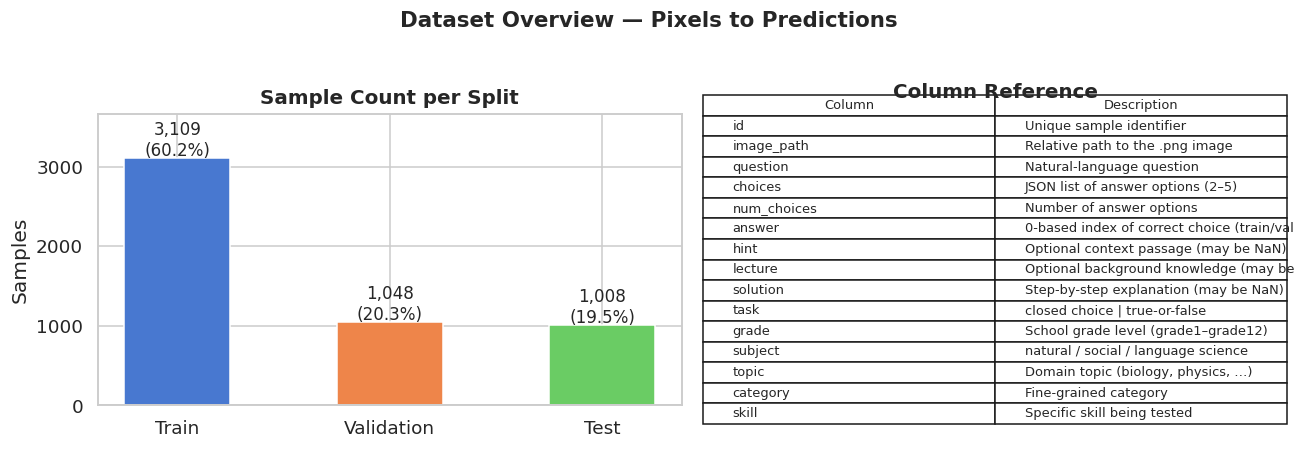

Total labeled samples (train+val): 4,157
Test samples (unlabeled):           1,008


In [22]:
# ── Split sizes ─────────────────────────────────────────────────────────────
sizes = {'Train': len(train_df), 'Validation': len(val_df), 'Test': len(test_df)}
total = sum(sizes.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(sizes.keys(), sizes.values(), color=PALETTE[:3], width=0.5, edgecolor='white')
for bar, val in zip(bars, sizes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Sample Count per Split', fontsize=13, fontweight='bold')
ax.set_ylabel('Samples')
ax.set_ylim(0, max(sizes.values()) * 1.18)

# Columns overview
ax2 = axes[1]
ax2.axis('off')
cols_info = [
    ('id',            'Unique sample identifier'),
    ('image_path',    'Relative path to the .png image'),
    ('question',      'Natural-language question'),
    ('choices',       'JSON list of answer options (2–5)'),
    ('num_choices',   'Number of answer options'),
    ('answer',        '0-based index of correct choice (train/val only)'),
    ('hint',          'Optional context passage (may be NaN)'),
    ('lecture',       'Optional background knowledge (may be NaN)'),
    ('solution',      'Step-by-step explanation (may be NaN)'),
    ('task',          'closed choice | true-or-false'),
    ('grade',         'School grade level (grade1–grade12)'),
    ('subject',       'natural / social / language science'),
    ('topic',         'Domain topic (biology, physics, …)'),
    ('category',      'Fine-grained category'),
    ('skill',         'Specific skill being tested'),
]
table_data = [[c, d] for c, d in cols_info]
tbl = ax2.table(cellText=table_data, colLabels=['Column', 'Description'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.3)
ax2.set_title('Column Reference', fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Dataset Overview — Pixels to Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total labeled samples (train+val): {len(train_df)+len(val_df):,}')
print(f'Test samples (unlabeled):           {len(test_df):,}')

<a id='3'></a>
## 3. Label & Answer Analysis

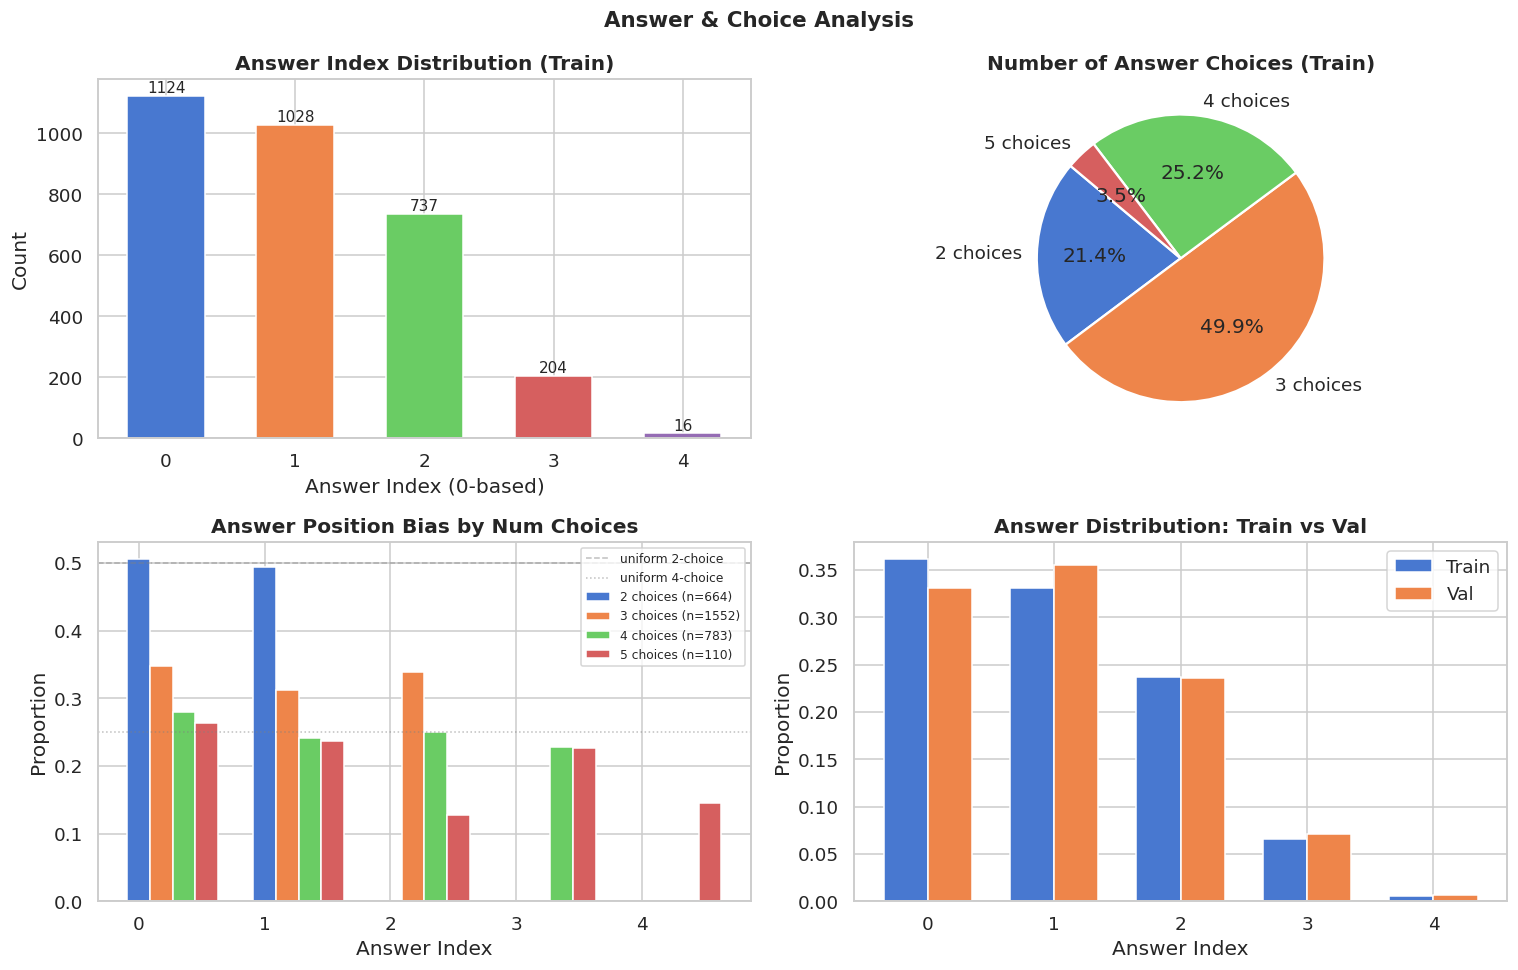


⚠️  Observations:
  • Answer index 0 is most common (~36% of train) — position bias exists!
  • Most samples have 3 choices (50%), followed by 4 (25%) and 2 (21%)
  • Train and Val answer distributions are well-matched


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 3a. Answer index distribution (train)
ax = axes[0, 0]
ans_counts = train_df['answer'].value_counts().sort_index()
bars = ax.bar(ans_counts.index, ans_counts.values,
              color=PALETTE[:len(ans_counts)], edgecolor='white', width=0.6)
for bar, val in zip(bars, ans_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=10)
ax.set_title('Answer Index Distribution (Train)', fontweight='bold')
ax.set_xlabel('Answer Index (0-based)')
ax.set_ylabel('Count')

# 3b. Number of choices distribution
ax = axes[0, 1]
nc_counts = train_df['num_choices'].value_counts().sort_index()
wedges, texts, autotexts = ax.pie(
    nc_counts.values,
    labels=[f'{k} choices' for k in nc_counts.index],
    autopct='%1.1f%%',
    colors=PALETTE,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Number of Answer Choices (Train)', fontweight='bold')

# 3c. Answer distribution within each num_choices group
ax = axes[1, 0]
nc_groups = sorted(train_df['num_choices'].unique())
x = np.arange(5)  # max 5 choices
width = 0.18
for i, nc in enumerate(nc_groups):
    sub = train_df[train_df['num_choices'] == nc]
    dist = sub['answer'].value_counts(normalize=True).reindex(range(nc), fill_value=0)
    ax.bar(dist.index + i * width, dist.values, width=width,
           label=f'{nc} choices (n={len(sub)})', color=PALETTE[i])
ax.axhline(y=1/2, color='gray', ls='--', lw=1, alpha=0.5, label='uniform 2-choice')
ax.axhline(y=1/4, color='gray', ls=':', lw=1, alpha=0.5, label='uniform 4-choice')
ax.set_title('Answer Position Bias by Num Choices', fontweight='bold')
ax.set_xlabel('Answer Index')
ax.set_ylabel('Proportion')
ax.legend(fontsize=8)

# 3d. Train vs Val answer distribution comparison
ax = axes[1, 1]
train_norm = train_df['answer'].value_counts(normalize=True).sort_index()
val_norm   = val_df['answer'].value_counts(normalize=True).sort_index()
idx = sorted(set(train_norm.index) | set(val_norm.index))
w = 0.35
ax.bar(np.array(idx) - w/2,
       [train_norm.get(i, 0) for i in idx], width=w,
       label='Train', color=PALETTE[0])
ax.bar(np.array(idx) + w/2,
       [val_norm.get(i, 0) for i in idx], width=w,
       label='Val', color=PALETTE[1])
ax.set_title('Answer Distribution: Train vs Val', fontweight='bold')
ax.set_xlabel('Answer Index')
ax.set_ylabel('Proportion')
ax.legend()

plt.suptitle('Answer & Choice Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n⚠️  Observations:')
print('  • Answer index 0 is most common (~36% of train) — position bias exists!')
print('  • Most samples have 3 choices (50%), followed by 4 (25%) and 2 (21%)')
print('  • Train and Val answer distributions are well-matched')

<a id='4'></a>
## 4. Question & Choice Analysis

/tmp/ipykernel_57/3145444617.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(nc_q, patch_artist=True,


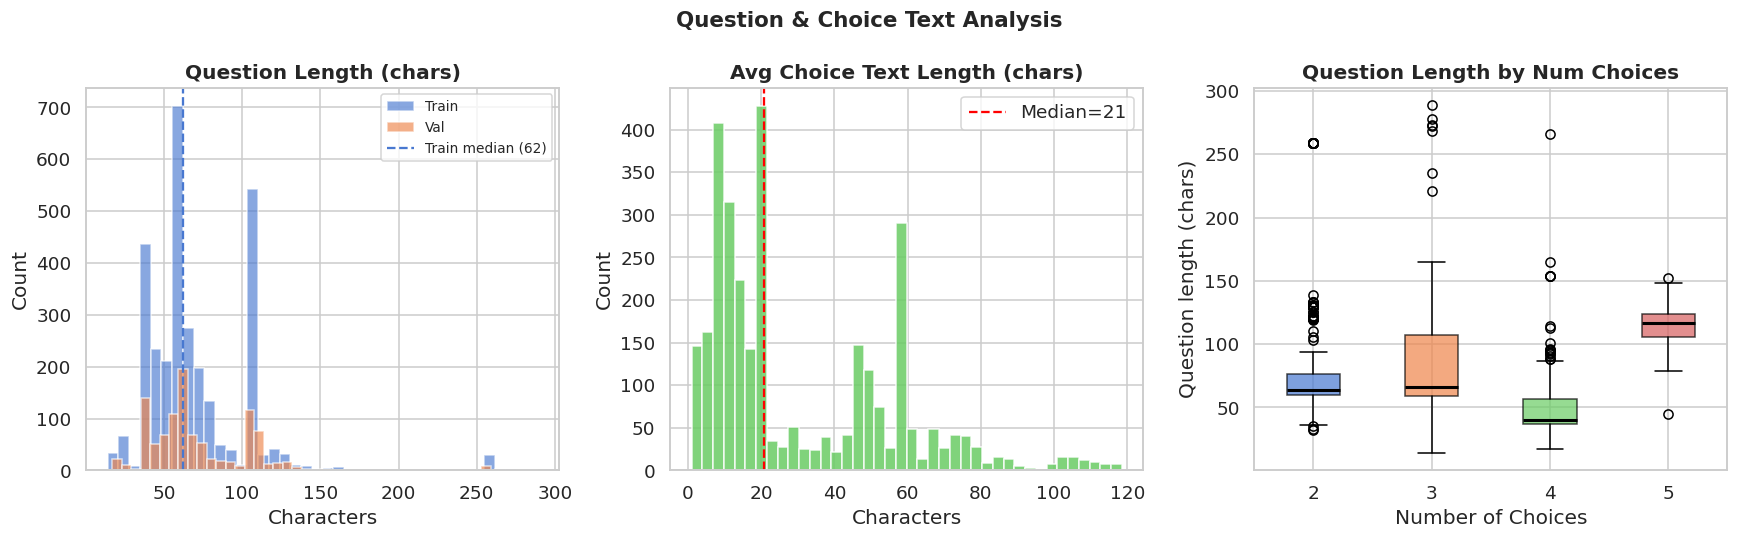

Mean question length:        70.7 chars
Median question length:      62 chars
Mean avg choice length:      30.8 chars
Longest question:            289 chars


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4a. Question length distribution
ax = axes[0]
for df, label, color in zip([train_df, val_df], ['Train', 'Val'], PALETTE):
    ax.hist(df['q_len'], bins=40, alpha=0.65, label=label, color=color, edgecolor='white')
ax.axvline(train_df['q_len'].median(), color=PALETTE[0], ls='--', lw=1.5,
           label=f'Train median ({train_df["q_len"].median():.0f})')
ax.set_title('Question Length (chars)', fontweight='bold')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# 4b. Avg choice text length
ax = axes[1]
ax.hist(train_df['choices_text_len'], bins=40, color=PALETTE[2], edgecolor='white', alpha=0.85)
ax.axvline(train_df['choices_text_len'].median(), color='red', ls='--', lw=1.5,
           label=f'Median={train_df["choices_text_len"].median():.0f}')
ax.set_title('Avg Choice Text Length (chars)', fontweight='bold')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend()

# 4c. Question length vs num_choices
ax = axes[2]
nc_q = [train_df[train_df['num_choices'] == nc]['q_len'].values
        for nc in sorted(train_df['num_choices'].unique())]
bp = ax.boxplot(nc_q, patch_artist=True,
                labels=[f'{nc}' for nc in sorted(train_df['num_choices'].unique())],
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Question Length by Num Choices', fontweight='bold')
ax.set_xlabel('Number of Choices')
ax.set_ylabel('Question length (chars)')

plt.suptitle('Question & Choice Text Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean question length:        {train_df["q_len"].mean():.1f} chars')
print(f'Median question length:      {train_df["q_len"].median():.0f} chars')
print(f'Mean avg choice length:      {train_df["choices_text_len"].mean():.1f} chars')
print(f'Longest question:            {train_df["q_len"].max()} chars')

In [25]:
# Task type breakdown
task_counts = train_df['task'].value_counts()
print('Task types in training set:')
for task, cnt in task_counts.items():
    print(f'  {task:<20} {cnt:>5}  ({cnt/len(train_df)*100:.1f}%)')

print()
print('True-or-false questions only appear in natural science.')
print('(closed choice = standard multiple choice, true-or-false = binary T/F)')

Task types in training set:
  closed choice         3071  (98.8%)
  true-or false           38  (1.2%)

True-or-false questions only appear in natural science.
(closed choice = standard multiple choice, true-or-false = binary T/F)


<a id='5'></a>
## 5. Subject / Topic / Skill Breakdown

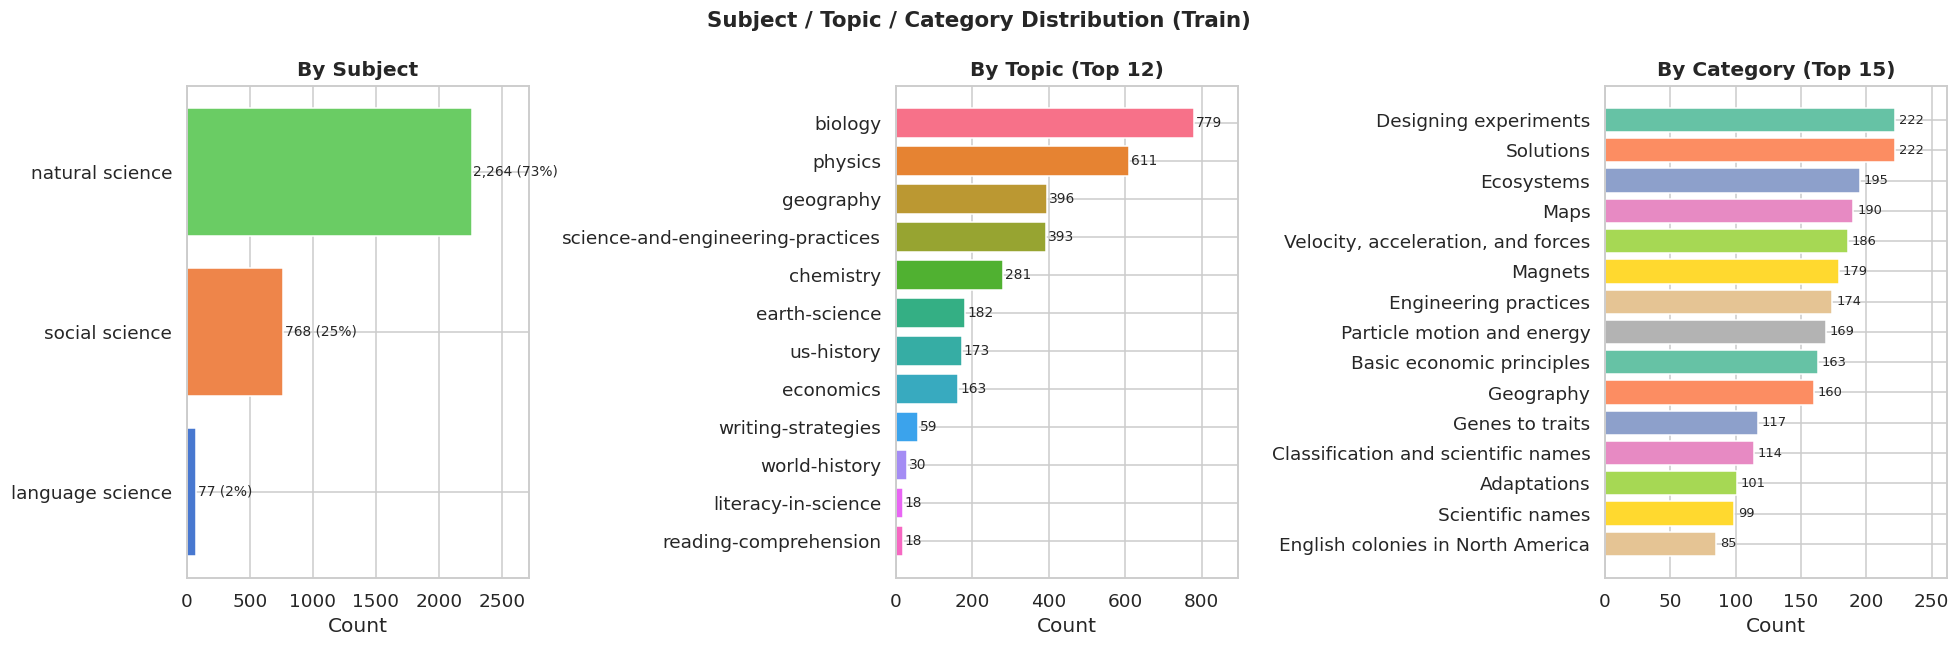

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 5a. Subject
ax = axes[0]
subj = train_df['subject'].value_counts()
ax.barh(subj.index[::-1], subj.values[::-1],
        color=PALETTE[:len(subj)], edgecolor='white')
for i, v in enumerate(subj.values[::-1]):
    ax.text(v + 10, i, f'{v:,} ({v/len(train_df)*100:.0f}%)', va='center', fontsize=9)
ax.set_title('By Subject', fontweight='bold')
ax.set_xlabel('Count')
ax.set_xlim(0, subj.max() * 1.2)

# 5b. Topic
ax = axes[1]
top_topics = train_df['topic'].value_counts().head(12)
ax.barh(top_topics.index[::-1], top_topics.values[::-1],
        color=sns.color_palette('husl', 12)[::-1], edgecolor='white')
for i, v in enumerate(top_topics.values[::-1]):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
ax.set_title('By Topic (Top 12)', fontweight='bold')
ax.set_xlabel('Count')
ax.set_xlim(0, top_topics.max() * 1.15)

# 5c. Category top 15
ax = axes[2]
top_cat = train_df['category'].value_counts().head(15)
ax.barh(top_cat.index[::-1], top_cat.values[::-1],
        color=sns.color_palette('Set2', 15)[::-1], edgecolor='white')
for i, v in enumerate(top_cat.values[::-1]):
    ax.text(v + 3, i, str(v), va='center', fontsize=8.5)
ax.set_title('By Category (Top 15)', fontweight='bold')
ax.set_xlabel('Count')
ax.set_xlim(0, top_cat.max() * 1.18)

plt.suptitle('Subject / Topic / Category Distribution (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

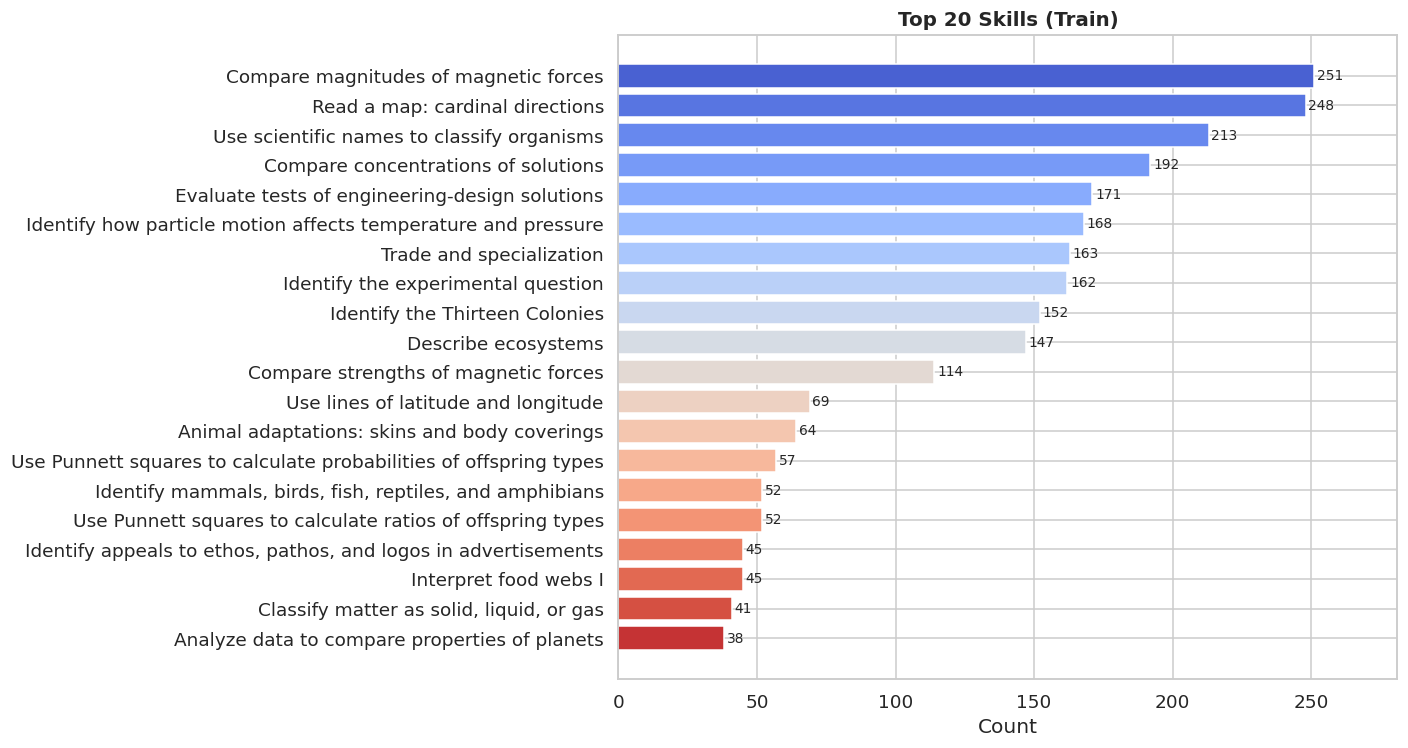


Total unique skills: 109
Total unique categories: 55
Total unique topics: 14


In [27]:
# Top 20 skills
fig, ax = plt.subplots(figsize=(13, 7))
top_skills = train_df['skill'].value_counts().head(20)
ax.barh(top_skills.index[::-1], top_skills.values[::-1],
        color=sns.color_palette('coolwarm', 20)[::-1], edgecolor='white')
for i, v in enumerate(top_skills.values[::-1]):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
ax.set_title('Top 20 Skills (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
ax.set_xlim(0, top_skills.max() * 1.12)
plt.tight_layout()
plt.show()

print(f'\nTotal unique skills: {train_df["skill"].nunique()}')
print(f'Total unique categories: {train_df["category"].nunique()}')
print(f'Total unique topics: {train_df["topic"].nunique()}')

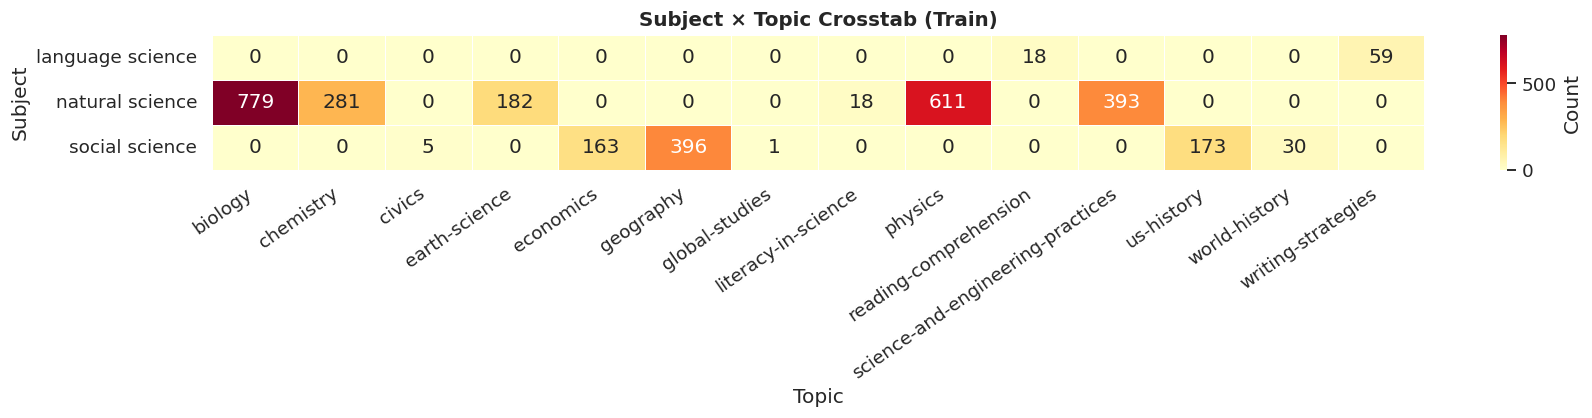

In [28]:
# Subject x Topic heatmap
pivot = pd.crosstab(train_df['subject'], train_df['topic'])
# Keep only topics present in the data
pivot = pivot.loc[:, pivot.sum() > 0]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Subject × Topic Crosstab (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Subject')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Grade Level Distribution

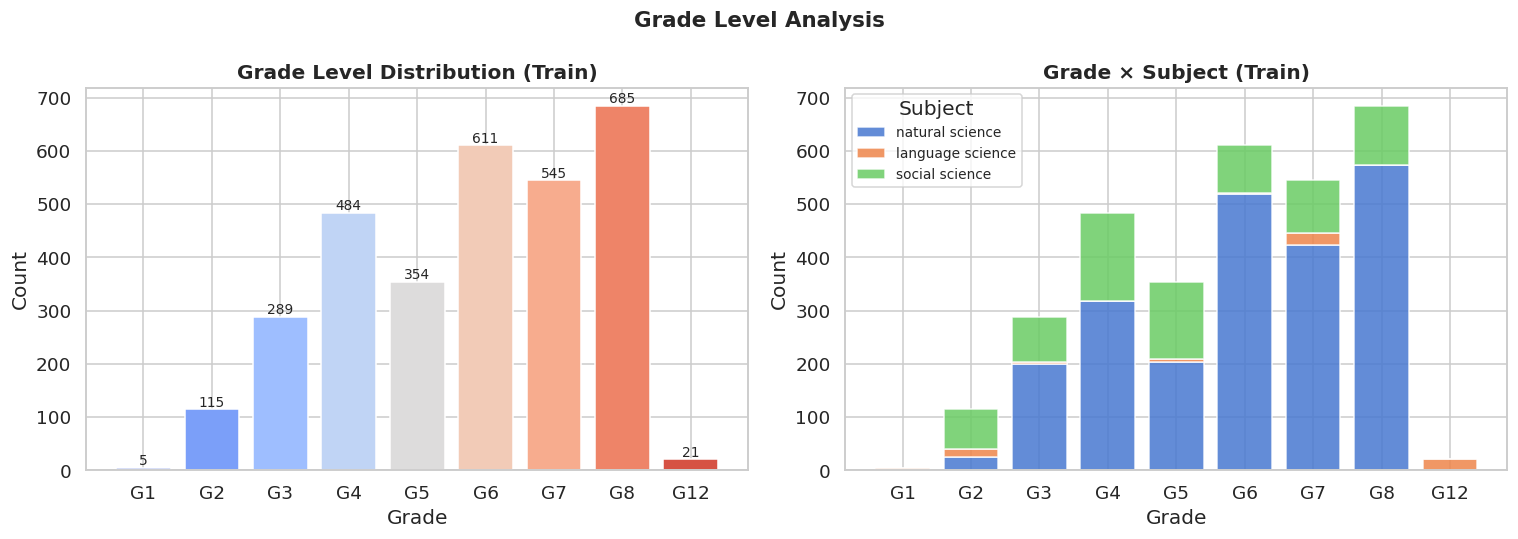

Grade distribution:
  grade1       5  (0.2%)
  grade2     115  (3.7%)
  grade3     289  (9.3%)
  grade4     484  (15.6%)
  grade5     354  (11.4%)
  grade6     611  (19.7%)
  grade7     545  (17.5%)
  grade8     685  (22.0%)
  grade12     21  (0.7%)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grade count
grade_order = [f'grade{i}' for i in range(1, 13)]
grade_counts = train_df['grade'].value_counts().reindex(
    [g for g in grade_order if g in train_df['grade'].values])

ax = axes[0]
colors = sns.color_palette('coolwarm', len(grade_counts))
bars = ax.bar(range(len(grade_counts)), grade_counts.values,
              color=colors, edgecolor='white')
ax.set_xticks(range(len(grade_counts)))
ax.set_xticklabels([g.replace('grade', 'G') for g in grade_counts.index])
for bar, val in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=9)
ax.set_title('Grade Level Distribution (Train)', fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')

# Grade × Subject stacked bar
ax = axes[1]
subjects = train_df['subject'].unique()
grade_subj = pd.crosstab(train_df['grade'], train_df['subject']).reindex(
    [g for g in grade_order if g in train_df['grade'].values])

bottom = np.zeros(len(grade_subj))
for i, subj in enumerate(subjects):
    if subj in grade_subj.columns:
        vals = grade_subj[subj].values
        ax.bar(range(len(grade_subj)), vals, bottom=bottom,
               label=subj, color=PALETTE[i], edgecolor='white', alpha=0.85)
        bottom += vals

ax.set_xticks(range(len(grade_subj)))
ax.set_xticklabels([g.replace('grade', 'G') for g in grade_subj.index])
ax.set_title('Grade × Subject (Train)', fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
ax.legend(title='Subject', fontsize=9)

plt.suptitle('Grade Level Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Grade distribution:')
for g, c in grade_counts.items():
    print(f'  {g:<8}  {c:>4}  ({c/len(train_df)*100:.1f}%)')

<a id='7'></a>
## 7. Missing Data Analysis

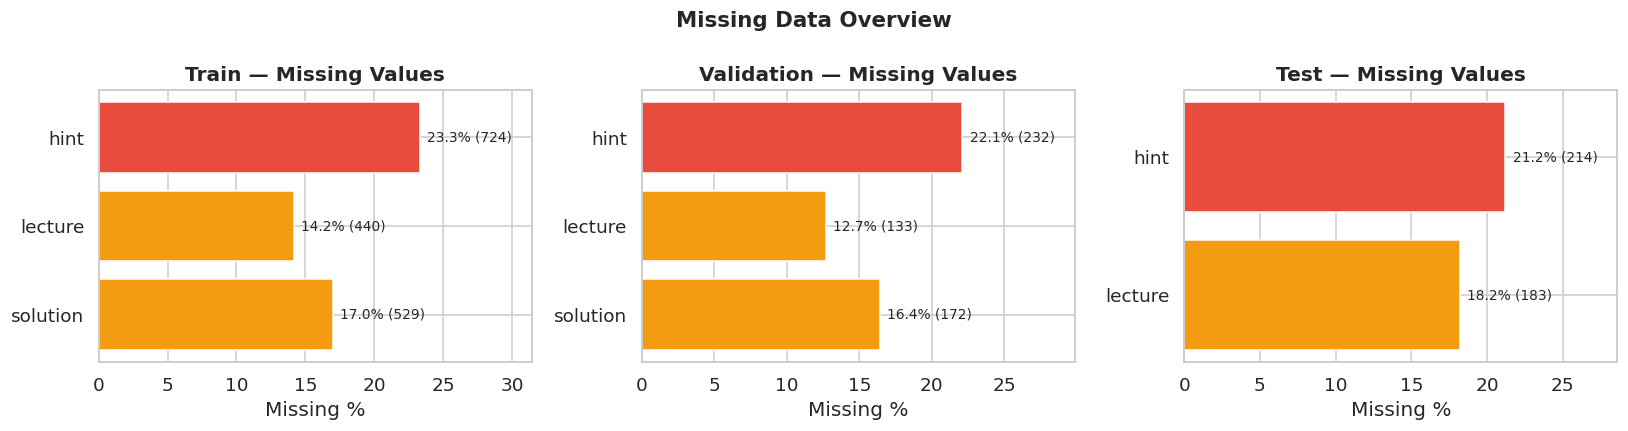


🔍 Notes on missing columns:
  • hint    — present only when the question has an explanatory passage
  • lecture — background knowledge text; absent for some questions
  • solution — full worked solution; absent for some questions
  → These are supplementary context fields that the VLM can optionally use
  → None are available in test.csv except for the hint column


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, df, title in zip(axes, [train_df, val_df, test_df],
                          ['Train', 'Validation', 'Test']):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
    else:
        pct = (missing / len(df) * 100).round(1)
        colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#27ae60'
                  for p in pct]
        bars = ax.barh(missing.index[::-1], pct.values[::-1],
                       color=colors[::-1], edgecolor='white')
        for bar, val, cnt in zip(bars, pct.values[::-1], missing.values[::-1]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val}% ({cnt:,})', va='center', fontsize=9)
        ax.set_xlim(0, pct.max() * 1.35)
        ax.set_xlabel('Missing %')
    ax.set_title(f'{title} — Missing Values', fontweight='bold')

plt.suptitle('Missing Data Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Notes on missing columns:')
print('  • hint    — present only when the question has an explanatory passage')
print('  • lecture — background knowledge text; absent for some questions')
print('  • solution — full worked solution; absent for some questions')
print('  → These are supplementary context fields that the VLM can optionally use')
print('  → None are available in test.csv except for the hint column')

<a id='8'></a>
## 8. Image Analysis — Size, Dimensions & Variety

In [31]:
# ── Load image metadata (fast — no full decode needed) ───────────────────────

def get_image_stats(image_root, n_sample=500, seed=42):
    """Sample images from the extracted image directory and return size/dimension stats."""
    rng = random.Random(seed)
    records = []
    root = Path(image_root)
    if not root.exists():
        print(f'⚠️  Image root not found: {root}')
        return pd.DataFrame()
    all_imgs = list(root.rglob('*.png'))
    sample = rng.sample(all_imgs, min(n_sample, len(all_imgs)))
    for p in sample:
        split = p.parent.name
        img = Image.open(p)
        w, h = img.size
        records.append({'path': str(p), 'split': split, 'width': w, 'height': h,
                        'file_size_kb': p.stat().st_size / 1024,
                        'aspect': w / h, 'mode': img.mode})
    return pd.DataFrame(records)


IMAGE_ROOT = Path('/kaggle/input/competitions/pixels-to-predictions/images/images')
print('Sampling images for statistics…')
img_stats = get_image_stats(IMAGE_ROOT, n_sample=600)

if len(img_stats) > 0:
    print(f'Sampled {len(img_stats)} images')
    print(img_stats.describe().round(1))


Sampling images for statistics…
Sampled 600 images
       width  height  file_size_kb  aspect
count  600.0   600.0         600.0   600.0
mean   440.2   285.7          74.6     1.8
std    192.8   130.0          75.2     1.4
min     93.0    80.0           0.9     0.6
25%    302.0   185.2          24.6     1.0
50%    395.0   241.0          54.3     1.3
75%    585.0   405.0          99.3     1.7
max    760.0   595.0         473.6     7.4


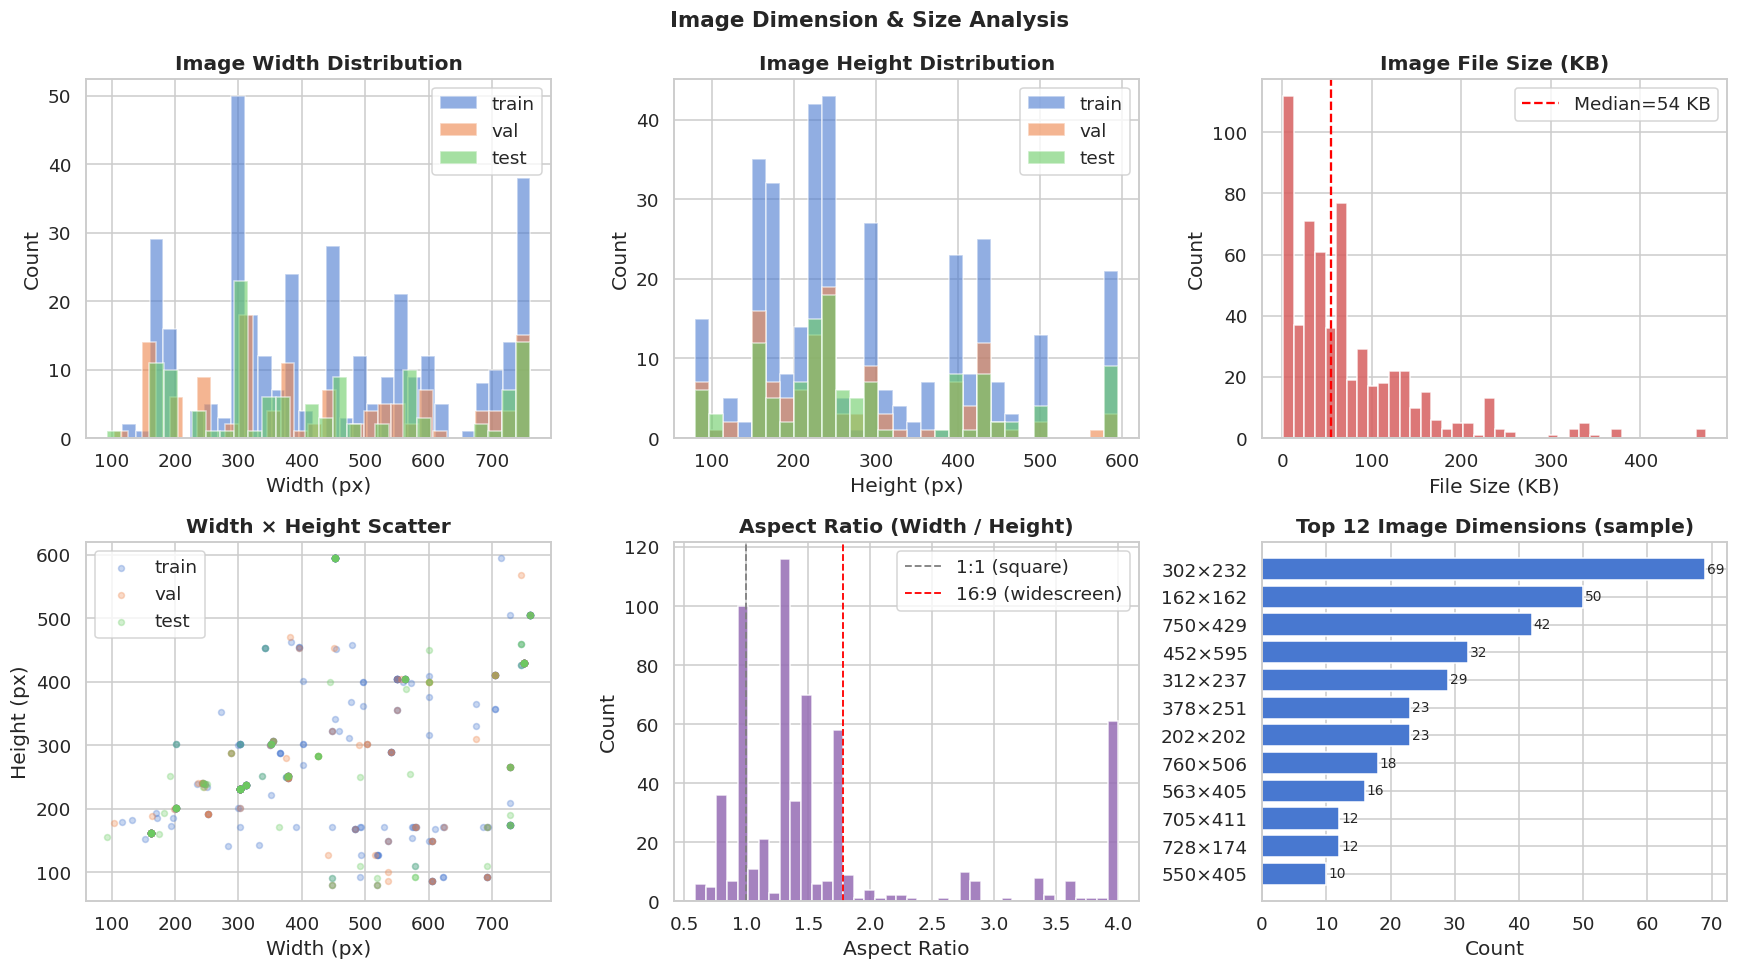


Width  — min:93px  max:760px  mean:440px
Height — min:80px  max:595px  mean:286px
File sizes — min:0.9KB  max:473.6KB  mean:74.6KB
Color modes: {'RGB': 600}


In [32]:
if len(img_stats) == 0:
    print('Skipping image plots — no images found.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    # 8a. Width distribution
    ax = axes[0, 0]
    for split, color in zip(['train', 'val', 'test'], PALETTE):
        sub = img_stats[img_stats['split'] == split]['width']
        if len(sub) > 0:
            ax.hist(sub, bins=30, alpha=0.6, label=split, color=color, edgecolor='white')
    ax.set_title('Image Width Distribution', fontweight='bold')
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Count')
    ax.legend()

    # 8b. Height distribution
    ax = axes[0, 1]
    for split, color in zip(['train', 'val', 'test'], PALETTE):
        sub = img_stats[img_stats['split'] == split]['height']
        if len(sub) > 0:
            ax.hist(sub, bins=30, alpha=0.6, label=split, color=color, edgecolor='white')
    ax.set_title('Image Height Distribution', fontweight='bold')
    ax.set_xlabel('Height (px)')
    ax.set_ylabel('Count')
    ax.legend()

    # 8c. File size distribution
    ax = axes[0, 2]
    ax.hist(img_stats['file_size_kb'], bins=40, color=PALETTE[3], edgecolor='white', alpha=0.85)
    ax.axvline(img_stats['file_size_kb'].median(), color='red', ls='--',
               label=f'Median={img_stats["file_size_kb"].median():.0f} KB')
    ax.set_title('Image File Size (KB)', fontweight='bold')
    ax.set_xlabel('File Size (KB)')
    ax.set_ylabel('Count')
    ax.legend()

    # 8d. Width × Height scatter
    ax = axes[1, 0]
    for split, color in zip(['train', 'val', 'test'], PALETTE):
        sub = img_stats[img_stats['split'] == split]
        ax.scatter(sub['width'], sub['height'], alpha=0.3, s=15,
                   label=split, color=color)
    ax.set_title('Width × Height Scatter', fontweight='bold')
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Height (px)')
    ax.legend()

    # 8e. Aspect ratio distribution
    ax = axes[1, 1]
    ax.hist(img_stats['aspect'].clip(0, 4), bins=40, color=PALETTE[4],
            edgecolor='white', alpha=0.85)
    ax.axvline(1.0, color='gray', ls='--', lw=1.2, label='1:1 (square)')
    ax.axvline(16/9, color='red', ls='--', lw=1.2, label='16:9 (widescreen)')
    ax.set_title('Aspect Ratio (Width / Height)', fontweight='bold')
    ax.set_xlabel('Aspect Ratio')
    ax.set_ylabel('Count')
    ax.legend()

    # 8f. Top common dimensions
    ax = axes[1, 2]
    dim_counts = Counter(zip(img_stats['width'], img_stats['height'])).most_common(12)
    labels = [f'{w}×{h}' for (w, h), _ in dim_counts]
    counts = [c for _, c in dim_counts]
    ax.barh(labels[::-1], counts[::-1], color=PALETTE[0], edgecolor='white')
    for i, v in enumerate(counts[::-1]):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
    ax.set_title('Top 12 Image Dimensions (sample)', fontweight='bold')
    ax.set_xlabel('Count')

    plt.suptitle('Image Dimension & Size Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\nWidth  — min:{img_stats["width"].min()}px  max:{img_stats["width"].max()}px  mean:{img_stats["width"].mean():.0f}px')
    print(f'Height — min:{img_stats["height"].min()}px  max:{img_stats["height"].max()}px  mean:{img_stats["height"].mean():.0f}px')
    print(f'File sizes — min:{img_stats["file_size_kb"].min():.1f}KB  max:{img_stats["file_size_kb"].max():.1f}KB  mean:{img_stats["file_size_kb"].mean():.1f}KB')
    print(f'Color modes: {img_stats["mode"].value_counts().to_dict()}')

<a id='9'></a>
## 9. Image Visual Gallery — Diverse Examples

In [33]:
def load_image_from_df_row(row, image_root=None):
    """Load image referenced in a DataFrame row."""
    root = Path(image_root) if image_root else Path('/kaggle/input/competitions/pixels-to-predictions/images/images')
    # image_path in CSV is like 'images/train/train_00000.png'
    # strip leading 'images/' prefix since IMAGE_ROOT already points to images/images/
    img_rel = row['image_path']
    # Try direct join first
    candidate = root / img_rel
    if candidate.exists():
        return Image.open(candidate)
    # Strip one 'images/' prefix level if present
    if img_rel.startswith('images/'):
        candidate2 = root / img_rel[len('images/'):]
        if candidate2.exists():
            return Image.open(candidate2)
    # Fallback: search by filename
    fname = Path(img_rel).name
    matches = list(root.rglob(fname))
    if matches:
        return Image.open(matches[0])
    return None


print('Image loader ready ✓')


Image loader ready ✓


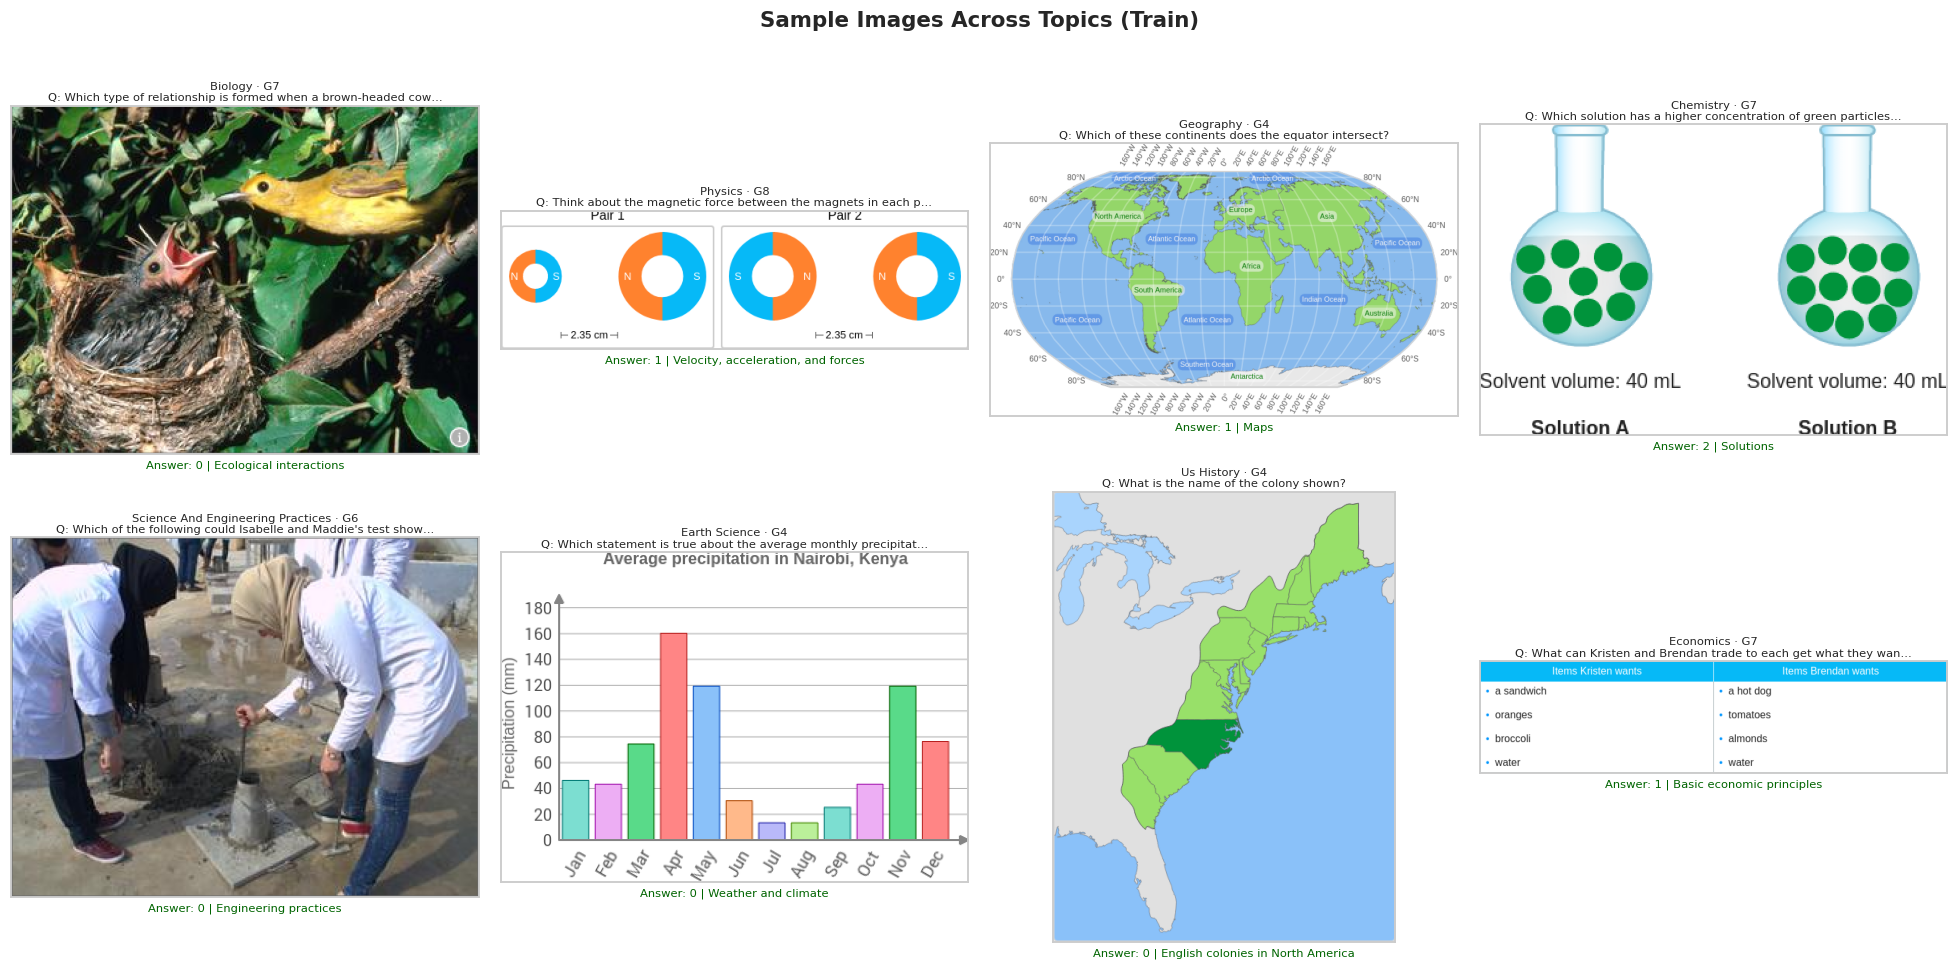

In [34]:
# ── Gallery: sample questions across categories ──────────────────────────
# Pick one example per topic to show diversity
gallery_topics = [
    'biology', 'physics', 'geography', 'chemistry',
    'science-and-engineering-practices', 'earth-science',
    'us-history', 'economics'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, topic in enumerate(gallery_topics):
    ax = axes[i]
    sub = train_df[train_df['topic'] == topic]
    if len(sub) == 0:
        ax.axis('off')
        continue
    row = sub.sample(1, random_state=i).iloc[0]
    img = load_image_from_df_row(row)
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, '[Image not found]\nRun on Kaggle or\nextract zip first',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='gray')
    # Wrap question text
    q = row['question'][:80] + ('…' if len(row['question']) > 80 else '')
    choices = row['choices_list']
    ax.set_title(
        f"{topic.replace('-', ' ').title()} · G{row['grade'].replace('grade','')}\n"
        f"Q: {q[:60]}{'…' if len(q) > 60 else ''}",
        fontsize=7.5, pad=3
    )
    ax.set_xlabel(f"Answer: {row['answer']} | {row['category']}",
                  fontsize=7.5, color='darkgreen')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Sample Images Across Topics (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

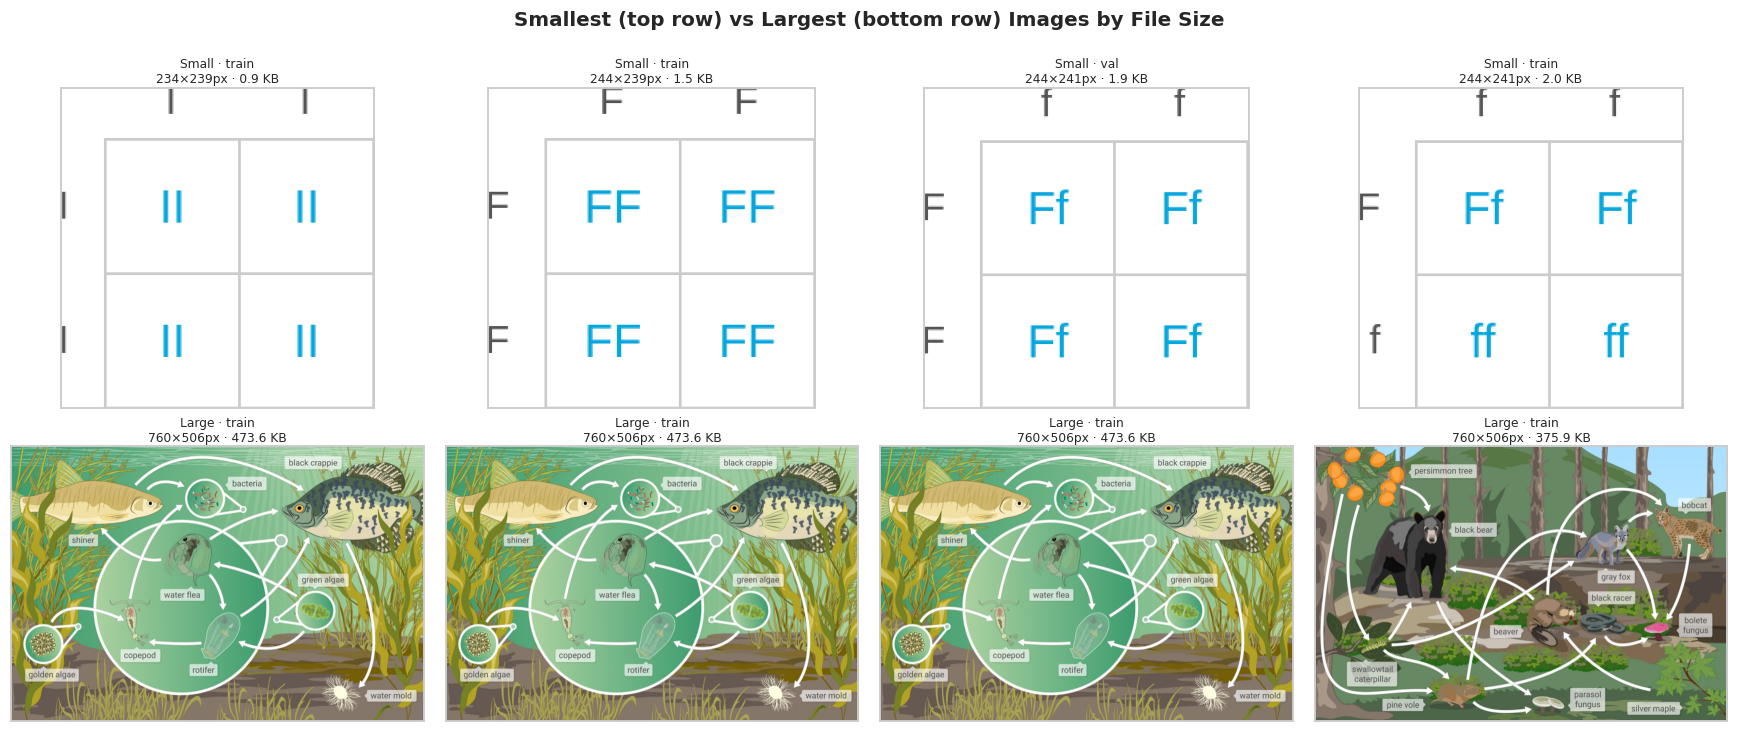

In [35]:
# ── Gallery: smallest vs largest images ──────────────────────────────────
# Show the range of image complexity
if len(img_stats) > 0:
    smallest = img_stats.nsmallest(4, 'file_size_kb').reset_index(drop=True)
    largest  = img_stats.nlargest(4, 'file_size_kb').reset_index(drop=True)

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    fig.suptitle('Smallest (top row) vs Largest (bottom row) Images by File Size',
                 fontsize=13, fontweight='bold')

    for row_idx, (group, row_label) in enumerate([(smallest, 'Small'), (largest, 'Large')]):
        for col_idx, stat_row in group.iterrows():
            ax = axes[row_idx, col_idx]
            try:
                img = Image.open(stat_row['path'])
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, f'[Load error]\n{e}',
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=8, color='red')
            ax.set_title(
                f"{row_label} · {stat_row['split']}\n"
                f"{stat_row['width']:.0f}×{stat_row['height']:.0f}px · {stat_row['file_size_kb']:.1f} KB",
                fontsize=8, pad=3
            )
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


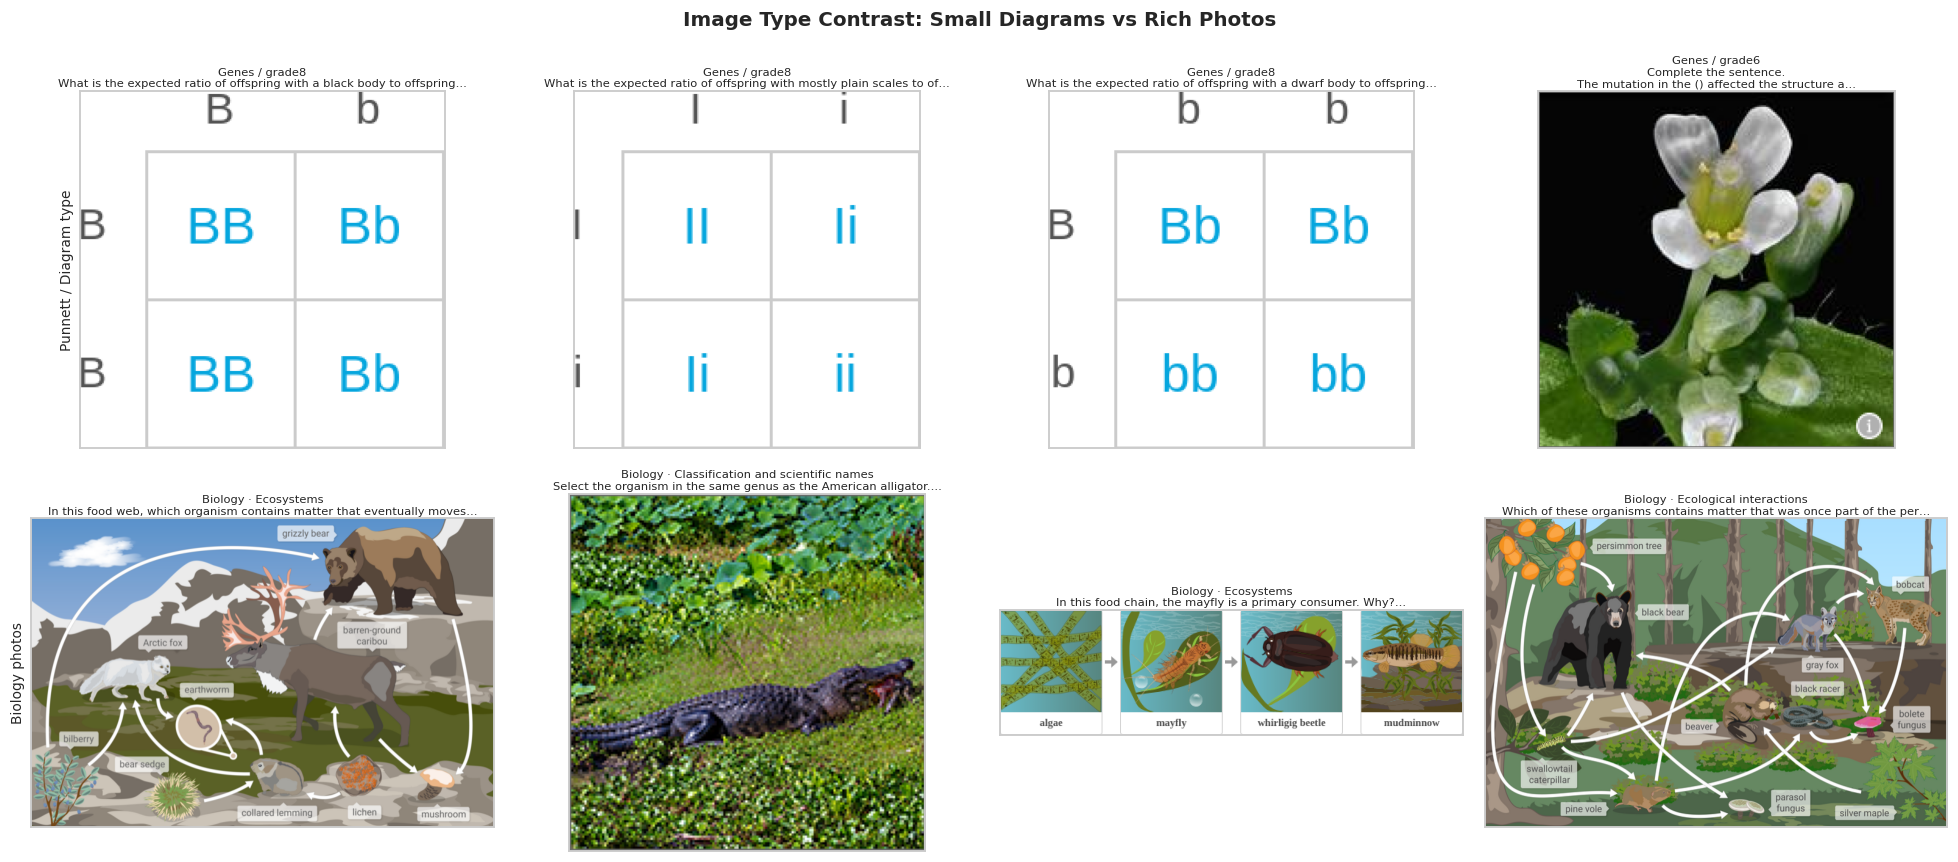

In [36]:
# ── Actual image grid: small Punnett squares vs rich photos ──────────────
# Pick from known categories: Genes to traits (small diagrams) vs biology photos

punnett = train_df[train_df['category'] == 'Genes to traits'].sample(4, random_state=1)
bio     = train_df[
    (train_df['topic'] == 'biology') &
    (~train_df['category'].isin(['Genes to traits', 'Scientific names']))
].sample(4, random_state=7)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, (_, row) in enumerate(punnett.iterrows()):
    ax = axes[0, i]
    img = load_image_from_df_row(row)
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, '[Punnett Square]\n(not loaded)',
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='steelblue')
    q = row['question'][:70] + '…'
    ax.set_title(f'Genes / {row["grade"]}\n{q}', fontsize=7.5, pad=3)
    ax.set_xticks([]); ax.set_yticks([])

for i, (_, row) in enumerate(bio.iterrows()):
    ax = axes[1, i]
    img = load_image_from_df_row(row)
    if img is not None:
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, '[Biology photo]\n(not loaded)',
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='forestgreen')
    q = row['question'][:70] + '…'
    ax.set_title(f'Biology · {row["category"]}\n{q}', fontsize=7.5, pad=3)
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel('Punnett / Diagram type', fontsize=9, rotation=90)
axes[1, 0].set_ylabel('Biology photos', fontsize=9, rotation=90)

plt.suptitle('Image Type Contrast: Small Diagrams vs Rich Photos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Key Takeaways for Modeling

In [37]:
print('=' * 70)
print('PIXELS TO PREDICTIONS — EDA SUMMARY & MODELING IMPLICATIONS')
print('=' * 70)

print('''
📊 DATASET STRUCTURE
  • 3,109 train | 1,048 val | 1,008 test samples
  • Each sample = image + question + 2–5 answer choices
  • Labels are 0-based answer indices (integer)
  • Based on the ScienceQA benchmark (education grade 1–12)

⚠️  ANSWER POSITION BIAS
  • Answer index 0 is chosen 36% of the time in train
  • Drops to ~23% for 5-choice questions (closer to uniform)
  ➜ Model may overfit to position; use cyclic-permutation TTA
     (rotate answer options and aggregate probabilities) to debias

📐 IMAGE DIVERSITY
  • Highly variable image sizes: tiny 152×80 Punnett squares to
    full-size 760×595 photographs
  • All images are RGB PNG, mean ~71 KB file size
  • Two main visual archetypes:
    (a) Diagrams / tables / maps — minimal, high-information-density
    (b) Nature / science photos — complex visual context
  ➜ Use a robust image resize/pad strategy; 320–384px edge works well
     for SmolVLM. Diagrams are readable even at smaller sizes.

📚 SUBJECT IMBALANCE
  • Natural science dominates (73%), social science 25%, language 2%
  • Biology (25%) and physics (20%) are the largest topics
  ➜ Monitor per-subject accuracy; consider subject-stratified val split

🎓 GRADE SKEW
  • Grade 8 and 6 have the most samples; grades 1, 12 are scarce
  ➜ Model should generalise across difficulty levels; no grade-specific
     fine-tuning recommended unless you have abundant higher-grade data

🔤 MISSING CONTEXT FIELDS
  • hint (23%), lecture (14%), solution (17%) are NaN for many rows
  ➜ Do NOT rely on these at inference time; the test set has similar gaps
  ➜ When present, hint text is the most useful (it's the reading passage)

🧠 MODELING STRATEGY
  1. Fine-tune SmolVLM-500M-Instruct with LoRA on the image+question+choices
  2. Prompt format: "<image>\nQuestion: {q}\nChoices: A) ... B) ... → Answer:"
  3. Use TTA via cyclic choice permutation to reduce position bias
  4. Validate on the provided val split (do NOT use it for training)
  5. Submit the better of plain / TTA predictions (they differ ~5–10%)
''')
print('=' * 70)

PIXELS TO PREDICTIONS — EDA SUMMARY & MODELING IMPLICATIONS

📊 DATASET STRUCTURE
  • 3,109 train | 1,048 val | 1,008 test samples
  • Each sample = image + question + 2–5 answer choices
  • Labels are 0-based answer indices (integer)
  • Based on the ScienceQA benchmark (education grade 1–12)

⚠️  ANSWER POSITION BIAS
  • Answer index 0 is chosen 36% of the time in train
  • Drops to ~23% for 5-choice questions (closer to uniform)
  ➜ Model may overfit to position; use cyclic-permutation TTA
     (rotate answer options and aggregate probabilities) to debias

📐 IMAGE DIVERSITY
  • Highly variable image sizes: tiny 152×80 Punnett squares to
    full-size 760×595 photographs
  • All images are RGB PNG, mean ~71 KB file size
  • Two main visual archetypes:
    (a) Diagrams / tables / maps — minimal, high-information-density
    (b) Nature / science photos — complex visual context
  ➜ Use a robust image resize/pad strategy; 320–384px edge works well
     for SmolVLM. Diagrams are readable e

In [38]:
# ── Final summary table ──────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total labeled samples',
        'Test samples',
        'Most common num_choices',
        'Answer 0 frequency (train)',
        'Dominant subject',
        'Dominant topic',
        'Most common skill',
        'Avg question length',
        'Image color mode',
        'Typical image size',
        'Task type',
    ],
    'Value': [
        f'{len(train_df)+len(val_df):,}',
        f'{len(test_df):,}',
        f'{train_df["num_choices"].mode()[0]} choices ({(train_df["num_choices"]==3).mean()*100:.0f}% of train)',
        f'{(train_df["answer"]==0).mean()*100:.1f}%',
        f'{train_df["subject"].mode()[0]} ({(train_df["subject"]=="natural science").mean()*100:.0f}%)',
        f'{train_df["topic"].mode()[0]} ({train_df["topic"].value_counts().iloc[0]} samples)',
        f'{train_df["skill"].mode()[0][:45]}…',
        f'{train_df["q_len"].mean():.0f} chars (median {train_df["q_len"].median():.0f})',
        'RGB PNG',
        '~302×232 px (highly variable)',
        '98.8% closed choice, 1.2% true-or-false',
    ]
})
print(summary.to_string(index=False))

                    Metric                                   Value
     Total labeled samples                                   4,157
              Test samples                                   1,008
   Most common num_choices                3 choices (50% of train)
Answer 0 frequency (train)                                   36.2%
          Dominant subject                   natural science (73%)
            Dominant topic                   biology (779 samples)
         Most common skill  Compare magnitudes of magnetic forces…
       Avg question length                    71 chars (median 62)
          Image color mode                                 RGB PNG
        Typical image size           ~302×232 px (highly variable)
                 Task type 98.8% closed choice, 1.2% true-or-false
